In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [4]:
df[df.duplicated()]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136539,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ


In [5]:
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  str    
dtypes: float64(14), int64(2), st

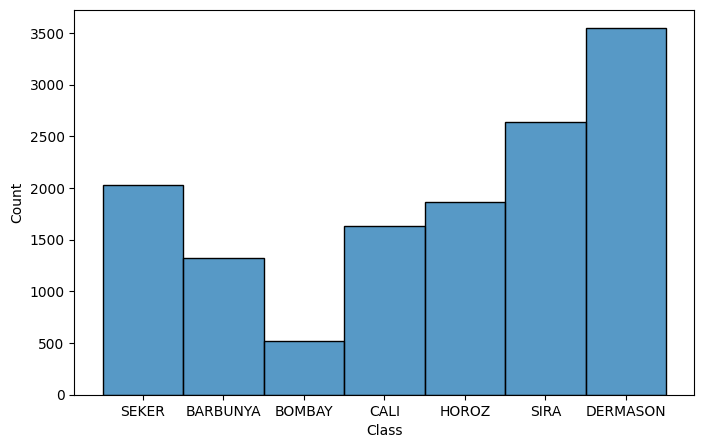

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Class"])
plt.show()

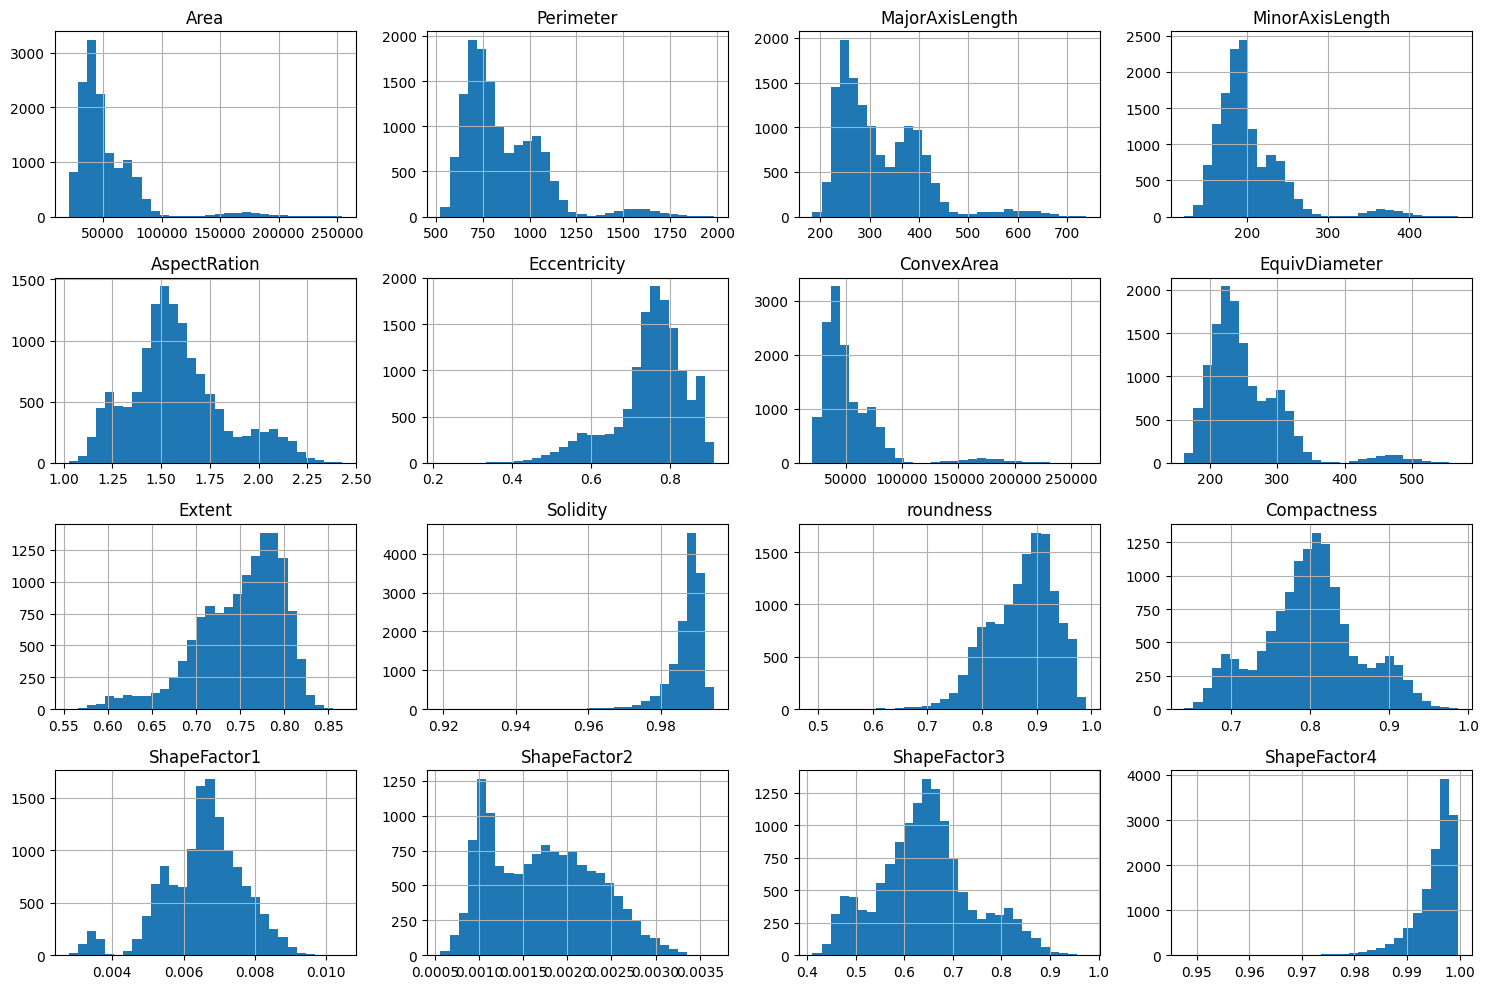

In [8]:
df.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

In [10]:
X = df.drop("Class", axis = 1).values
y = df["Class"].values

In [11]:
X.shape, y.shape

((13543, 16), (13543,))

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le = LabelEncoder()

In [14]:
y = le.fit_transform(y)

In [15]:
y

array([5, 5, 5, ..., 3, 3, 3], shape=(13543,))

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [22]:
from torch import nn

In [23]:
class MultiClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_stack_layer = nn.Sequential(
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,7)
        )

    def forward(self, x):
        return self.linear_stack_layer(x)

In [24]:
torch.manual_seed(23)

In [25]:
from torchmetrics.classification import MulticlassAccuracy

In [26]:
accuracy = MulticlassAccuracy(num_classes=7)

In [27]:
model = MultiClassifier()

In [28]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr = 0.003)

In [29]:
epochs = 501

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()

    with torch.inference_mode():

        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.5f}, Accuracy: {acc:.3f}, Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.3f}")

Epoch: 0, Loss: 1.97271, Accuracy: 14.286, Test Loss: 1.94370, Test Accuracy: 14.286
Epoch: 20, Loss: 1.20480, Accuracy: 66.647, Test Loss: 1.16900, Test Accuracy: 69.005
Epoch: 40, Loss: 0.55144, Accuracy: 86.416, Test Loss: 0.55003, Test Accuracy: 85.466
Epoch: 60, Loss: 0.33294, Accuracy: 90.401, Test Loss: 0.34932, Test Accuracy: 89.377
Epoch: 80, Loss: 0.25993, Accuracy: 92.050, Test Loss: 0.27930, Test Accuracy: 92.151
Epoch: 100, Loss: 0.22738, Accuracy: 92.971, Test Loss: 0.24600, Test Accuracy: 92.941
Epoch: 120, Loss: 0.21375, Accuracy: 93.282, Test Loss: 0.22962, Test Accuracy: 93.334
Epoch: 140, Loss: 0.20612, Accuracy: 93.386, Test Loss: 0.22102, Test Accuracy: 93.531
Epoch: 160, Loss: 0.20068, Accuracy: 93.551, Test Loss: 0.21553, Test Accuracy: 93.581
Epoch: 180, Loss: 0.19661, Accuracy: 93.700, Test Loss: 0.21213, Test Accuracy: 93.540
Epoch: 200, Loss: 0.19293, Accuracy: 93.802, Test Loss: 0.20942, Test Accuracy: 93.681
Epoch: 220, Loss: 0.18965, Accuracy: 93.938, Test

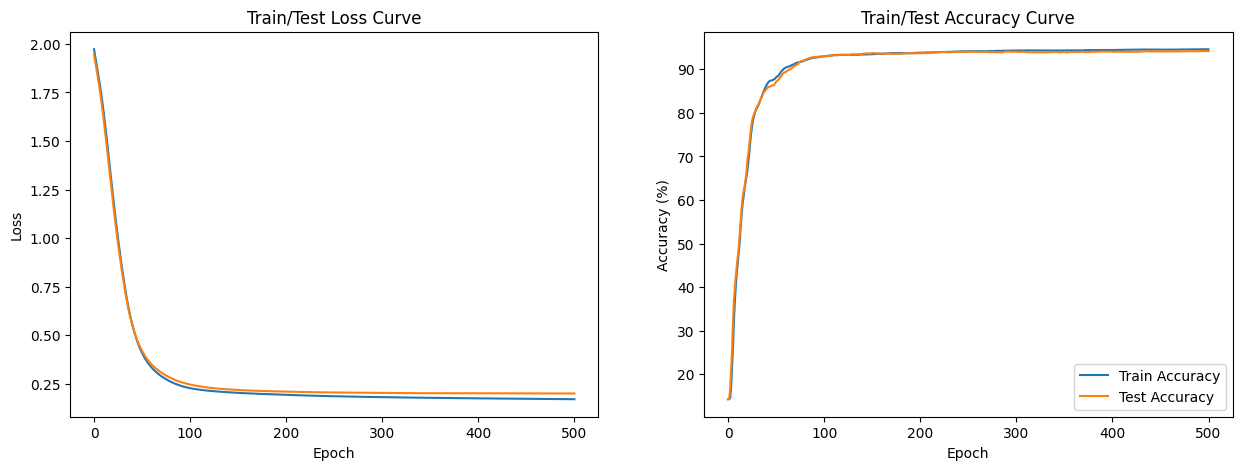

In [30]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label = "Train Loss")
plt.plot(test_losses, label = "Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

In [31]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [32]:
cm = MulticlassConfusionMatrix(num_classes=7)

In [33]:
matrix = cm(test_pred, y_test)

In [34]:
matrix

tensor([[246,   0,  12,   0,   0,   2,   5],
        [  0, 104,   0,   0,   0,   0,   0],
        [  8,   0, 314,   0,   1,   0,   3],
        [  0,   0,   0, 652,   1,  14,  42],
        [  2,   0,   6,   2, 354,   0,   8],
        [  2,   0,   0,   8,   0, 384,  12],
        [  2,   0,   1,  48,   8,   2, 466]])

In [35]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

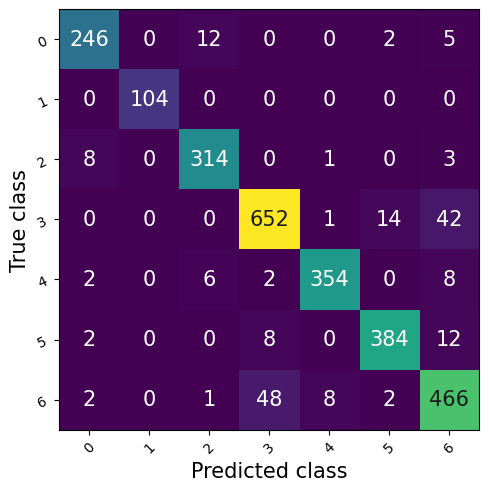

In [36]:
plot_confusion_matrix(matrix)